In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")

import warnings
warnings.filterwarnings("ignore")

ROOT = "."
b_models = pd.DataFrame()
full_models = pd.DataFrame()

def gather(MODEL):
    global b_models, full_models
    
    PATH = f"{ROOT}/{MODEL.lower()}/"
    torch2 = pd.read_csv(f"{PATH}/{MODEL}.csv")
    torch1 = pd.read_csv(f"{PATH}/torch1.8/{MODEL}-acceleration.csv")
    tf = pd.read_csv(f"{PATH}/tensorflow2.10/{MODEL}-acceleration.csv")

    dfs = [torch2, torch1, tf]

    for df in dfs:
        df.drop(
            columns="Unnamed: 0", inplace=True
        )
        # df.drop(
        #     df[df["pass"] == "Full"].index, inplace=True
        # )

    torch2, torch1, tf = dfs

    for i in [0, 3, 6]:
        torch1.at[i, "item"] = "Torch Script"

    f_base, b_base, fo, bo = [0] * 4
    dfs = [torch2, torch1, tf]

    for df in dfs:
        f_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Forward")]["time"])
        b_base += float(df[(torch2.item == "Nabla") & (df["pass"] == "Backward")]["time"])
        fo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Forward")]["time"])
        bo += float(df[(torch2.item == "Nabla Optim") & (df["pass"] == "Backward")]["time"])

    f_base, b_base, fo, bo = [x / 3 for x in [f_base, b_base, fo, bo]]
    full_base = f_base + b_base
    fullo = fo + bo

    nabla_df = pd.DataFrame({
        "time": [f_base, b_base, full_base, fo, bo, fullo],
        "pass": ["Forward", "Backward", "Full"] * 2,
        "item": ["Nabla"] * 3 + ["Nabla Optim"] * 3
    }, index=[0] * 6)

    for df in dfs:
        nabla_df = pd.concat([
            nabla_df, df[(df.item != "Nabla") & (df.item != "Nabla Optim")]
        ])

    nabla_df.style.hide(axis="index")
    nabla_df["model"] = MODEL
    f = nabla_df[nabla_df["pass"] == "Forward"]
    b = nabla_df[nabla_df["pass"] == "Backward"]
    full = nabla_df[nabla_df["pass"] == "Full"]
    f["acceleration"] = f_base / f["time"]
    b["acceleration"] = b_base / b["time"]
    full["acceleration"] = full_base / full["time"]

    b_models = pd.concat([b_models, b])
    full_models = pd.concat([full_models, full])

models = [
    "AlexNet",
    "ResNet18",
    "ResNet34",
    "ResNet50",
    "ResNet101",
    "ResNet152",
    "SqueezeNet",
    "VGG11",
    "VGG13",
    "VGG16",
    "VGG19"
]

for model in models:
    gather(model)

## Backward Pass

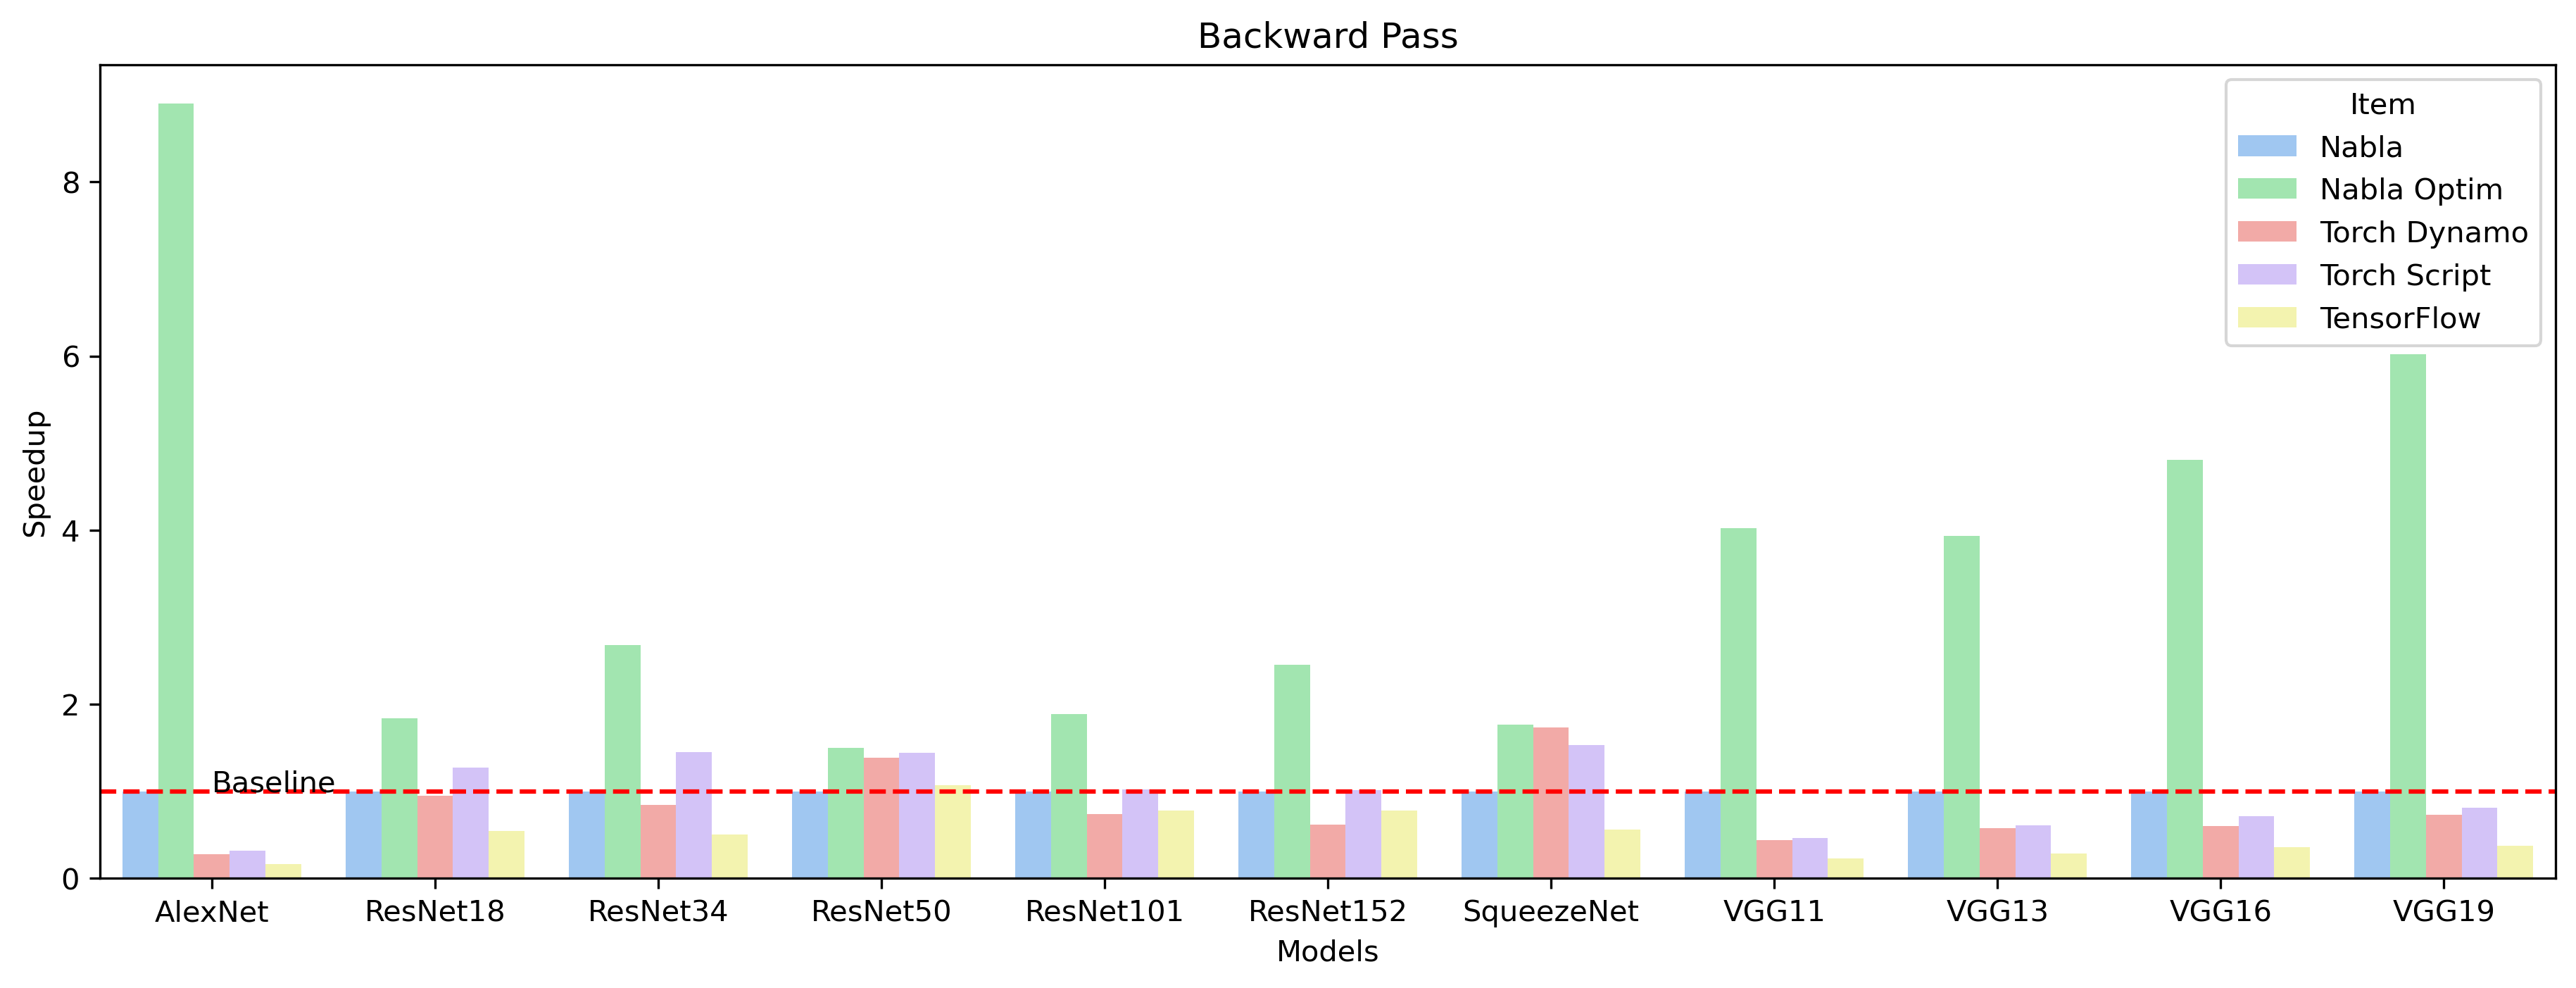

In [11]:
plt.figure(figsize=(15, 5))
plt.rcParams["figure.dpi"] = 300
sns.barplot(b_models, x="model", y="acceleration", hue="item")

plt.xlabel("Models")
plt.ylabel("Speedup")
plt.legend().set_title("Item")

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Baseline")

plt.title("Backward Pass")
plt.savefig("backward-pass.png", bbox_inches="tight", dpi=300, pad_inches=0.1)

## Full Pass

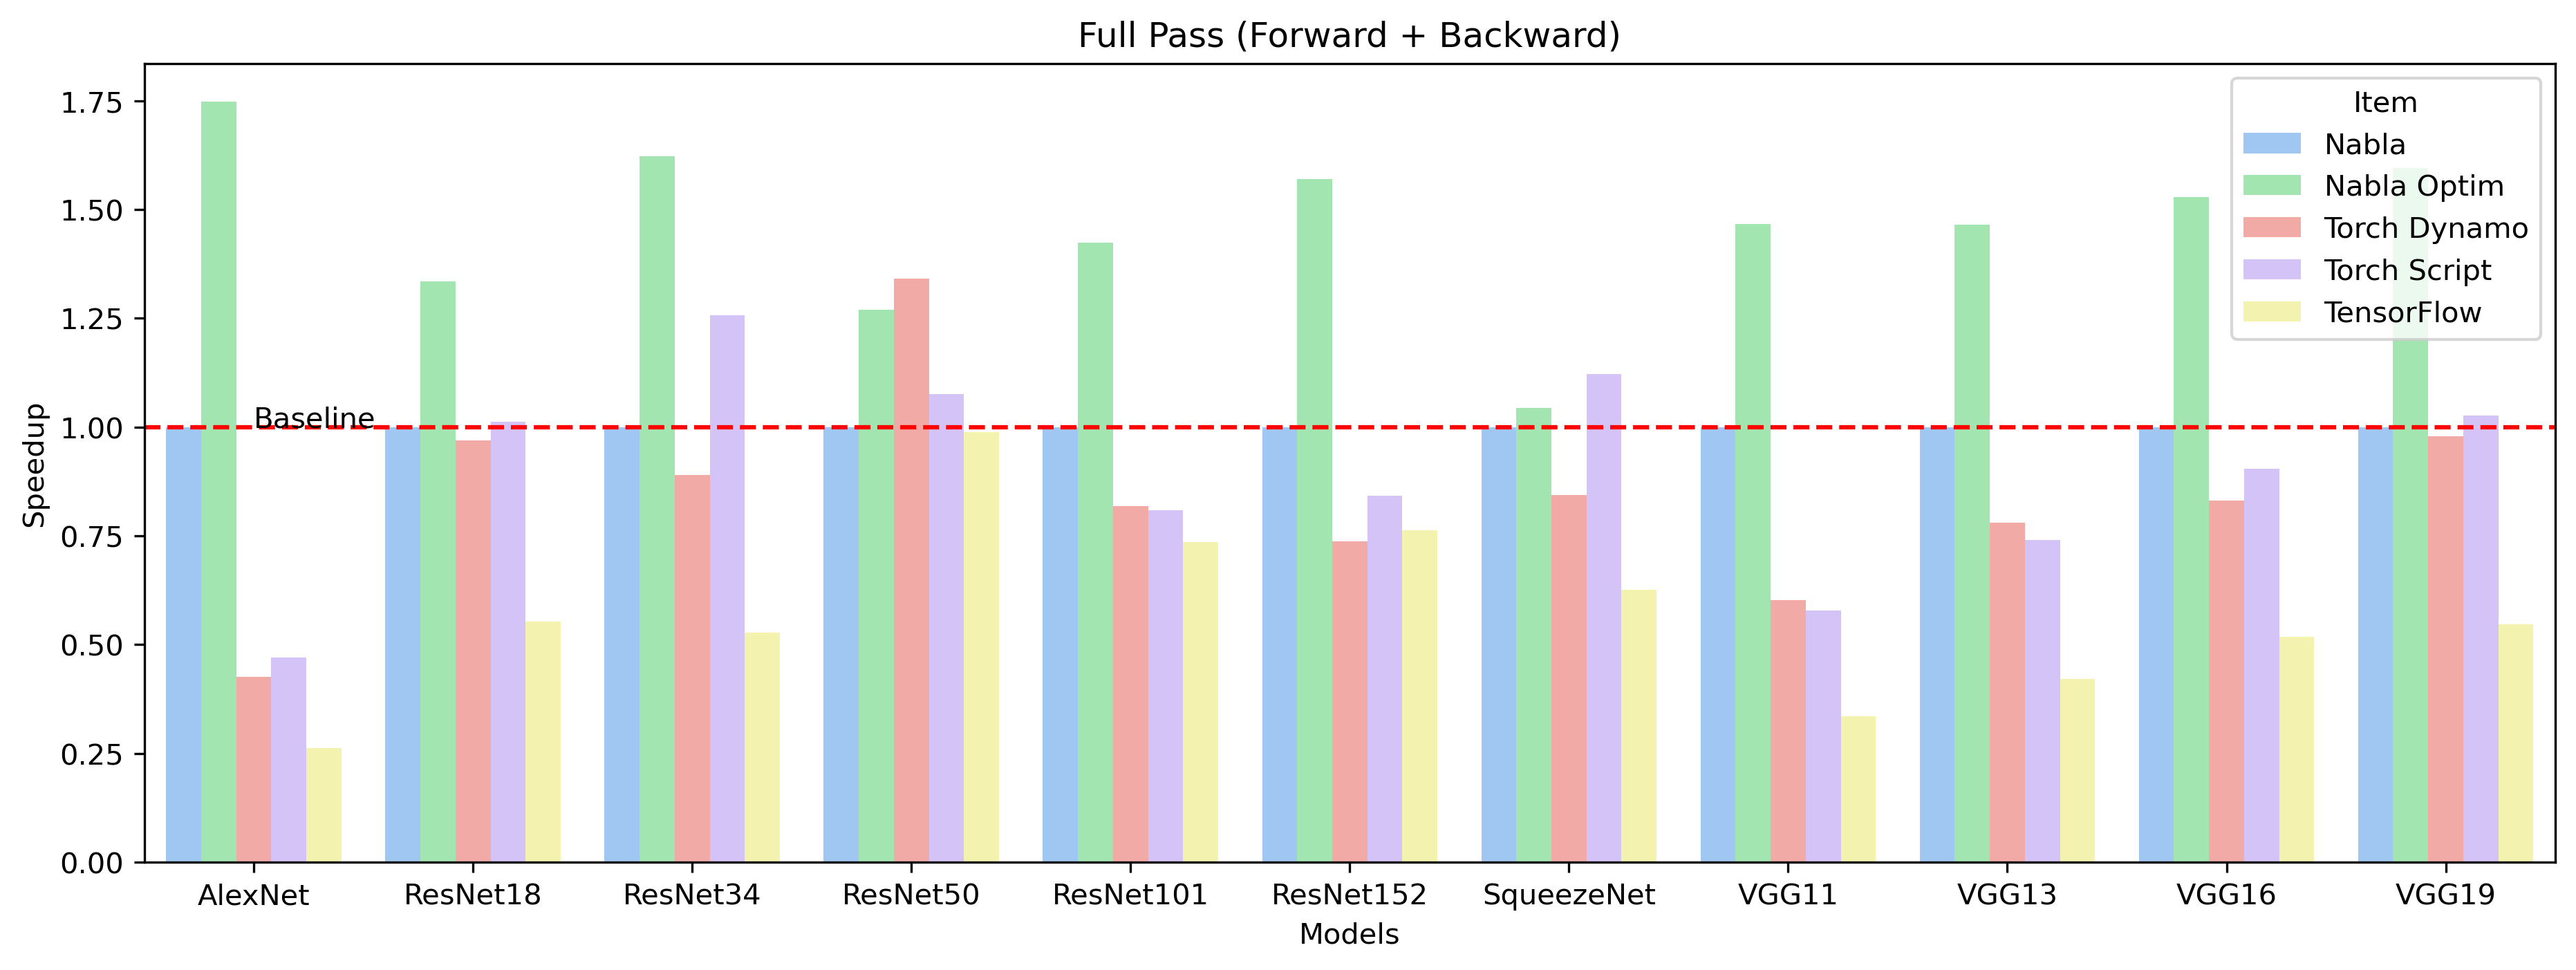

In [12]:
plt.figure(figsize=(15, 5))
plt.rcParams["figure.dpi"] = 300
sns.barplot(full_models, x="model", y="acceleration", hue="item")

plt.xlabel("Models")
plt.ylabel("Speedup")
plt.legend().set_title("Item")

plt.axhline(1, color="red", linestyle="--", label="Baseline")
plt.text(0, 1, "Baseline")

plt.title("Full Pass (Forward + Backward)")
plt.savefig("full-pass.png", bbox_inches="tight", dpi=300, pad_inches=0.1)